In [ ]:
from lib.oracle import run_oracle, safe_run_oracle
from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import matplotlib.pyplot as plt


# prueba corta de paralelsimo
import subprocess
import time
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed


# Ejemplo de uso
Se ejemplifica el uso de la herramienta para empezar

In [ ]:
# desviación del punto


In [ ]:
# - `physpoint`: wrapper para obtener los resultados del modelo
# - `loss`: métrica heurística (magnitud de los lambdas) para guiar la búsqueda


# Parámetros globales del modelo
lambda6 = 0.1
lambda7 = 0.0
# alpha = 1e-7
# beta  = 1.570796226794897
tan_beta = 1e4
sin_ba = 1

def physpoint(mphi: float, m12_2: float, mA: float = 300.0):
    # Llama al modelo con valores fijos y retorna el diccionario de resultados
    return safe_run_oracle([mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2])

def loss(mphi: float, m12_2: float, mA: float = 300.0):
    # Calcula una métrica basada en la suma de |lambda_i|
    output = physpoint(mphi, m12_2, mA)
    if output is None:
        return 1e14  # Penalización para errores o puntos no físicos
    return np.log(sum(np.abs(output[f'lambda{i}']) for i in range(1,6)) )

# Define función para verificar validez física del modelo
def is_valid(output: dict) -> bool:
    if output is None:
        return False
    return (
        output.get('positivity_ok', 0) == 1 and
        output.get('unitarity_ok', 0) == 1 and
        output.get('perturbativity_ok', 0) == 1
    )


### Testing multithreading of library

In [ ]:

# --------------------------------------
# 2) Genera un conjunto de inputs dummy
# --------------------------------------
# Por ejemplo 20 pares (mphi, m12)
inputs = [(125 + i*10, -0.1 + i*0.01) for i in range(20)]


# --------------------------------------------------
# 3) Medición secuencial para referencia
# --------------------------------------------------
t0 = time.time()
seq_results = [loss(m, x) for m, x in inputs]
t_seq = time.time() - t0
print(f"Secuencial: {t_seq:.2f} s")


# --------------------------------------------------
# 4) Medición con hilos (ThreadPoolExecutor)
# --------------------------------------------------
n_threads = 4
t0 = time.time()
with ThreadPoolExecutor(max_workers=n_threads) as exe:
    seq_fut = [exe.submit(loss, m, x) for m, x in inputs]
    thr_results = [f.result() for f in as_completed(seq_fut)]
t_thr = time.time() - t0
print(f"Multithreading ({n_threads} hilos): {t_thr:.2f} s")


# --------------------------------------------------
# 5) Medición con procesos (ProcessPoolExecutor)
# --------------------------------------------------
n_procs = 4
t0 = time.time()
with ProcessPoolExecutor(max_workers=n_procs) as exe:
    proc_fut = [exe.submit(loss, m, x) for m, x in inputs]
    proc_results = [f.result() for f in as_completed(proc_fut)]
t_proc = time.time() - t0
print(f"Multiprocessing ({n_procs} procesos): {t_proc:.2f} s")


# --------------------------------------------------
# 6) Resumen
# --------------------------------------------------
print()
print("Resumen de tiempos:")
print(f"- Secuencial        : {t_seq:.2f} s")
print(f"- Hilos ({n_threads})   : {t_thr:.2f} s  → x{t_seq/t_thr:.1f} speed-up")
print(f"- Procesos ({n_procs}) : {t_proc:.2f} s  → x{t_seq/t_proc:.1f} speed-up")

Secuencial: 0.53 s
Multithreading (4 hilos): 0.18 s
Multiprocessing (4 procesos): 0.22 s

Resumen de tiempos:
- Secuencial        : 0.53 s
- Hilos (4)   : 0.18 s  → x3.0 speed-up
- Procesos (4) : 0.22 s  → x2.4 speed-up


In [4]:
# Exploración sistemática de (mphi, m12) en una grilla
def explore_dense(mphi_range, m12_range, mA=300.0, max_loss=50):
    valid_points = []
    tested_points = []

    for mphi in mphi_range:
        for m12 in m12_range:
            out = physpoint(mphi, m12, mA)
            l = loss(mphi, m12, mA)
            tested_points.append((mphi, m12, l))

            if out is not None and l < max_loss and is_valid(out):
                valid_points.append({
                    'mphi': mphi,
                    'm12': m12,
                    'mA': mA,
                    'loss': l,
                    'output': out
                })

    return valid_points, tested_points


### Plots

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # aunque no se use directamente, activa el backend 3D
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates


def plot_exploration(valid_points, tested_points):
    import matplotlib.pyplot as plt

    # Separar datos
    all_mphi, all_m12, all_loss = zip(*tested_points)
    valid_mphi = [p['mphi'] for p in valid_points]
    valid_m12  = [p['m12'] for p in valid_points]

    fig, ax = plt.subplots(figsize=(8,6))
    sc = ax.scatter(all_mphi, all_m12, c=np.log10(all_loss), cmap='viridis', s=15)
    ax.scatter(valid_mphi, valid_m12, c='red', s=30, edgecolors='k', label='✓ físicos')

    ax.set_xlabel(r'$m_\phi$ [GeV]')
    ax.set_ylabel(r'$m_{12}$')
    ax.set_title(r'$\log_{10}$(loss) y puntos válidos')
    fig.colorbar(sc, label='log10(loss)')
    ax.legend()
    plt.show()


def plot_optimization_results(opt_result):
    X = np.array(opt_result.x_iters)
    y = np.array(opt_result.func_vals)

    fig, ax = plt.subplots(figsize=(8,6))
    sc = ax.scatter(X[:,0], X[:,1], c=np.log10(y), cmap='plasma', s=30)
    ax.set_xlabel(r'$m_\phi$')
    ax.set_ylabel(r'$m_{12}$')
    ax.set_title('Bayesian search: log10(loss)')
    fig.colorbar(sc, label='log10(loss)')
    plt.show()

def plot_optimization_results_3d(opt_result):
    X = np.array(opt_result.x_iters)    # shape (n_iter, 3)
    y = np.array(opt_result.func_vals)  # shape (n_iter,)

    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        X[:,0], X[:,1], X[:,2],
        c=np.log10(y), cmap='plasma', s=40, depthshade=True
    )
    ax.set_xlabel(r'$m_\phi$')
    ax.set_ylabel(r'$m_{12}$')
    ax.set_zlabel(r'$m_A$')
    ax.set_title('Bayesian search en 3D: log$_{10}$(loss)')
    fig.colorbar(sc, label='log$_{10}$(loss)', shrink=0.6)
    plt.tight_layout()
    plt.show()


def plot_pairwise(opt_result):
    X = np.array(opt_result.x_iters)
    y = np.array(opt_result.func_vals)

    # 1) DataFrame con logloss continuo
    df = pd.DataFrame({
        'mphi':    X[:,0],
        'm12':     X[:,1],
        'mA':      X[:,2],
        'logloss': np.log10(y)
    })

    # 2) Parejas (pairplot)
    sns.pairplot(df, vars=['mphi','m12','mA'],
                 hue='logloss', palette='plasma', diag_kind='kde')
    plt.suptitle('Pairplot de parámetros vs log10(loss)', y=1.02)
    plt.show()

    # 3) Creamos una variable categórica con 4 bins de logloss
    df['logloss_bin'] = pd.qcut(df['logloss'], q=4,
                                labels=['Q1','Q2','Q3','Q4'])

    # 4) Parallel coordinates con muestra segura
    n_sample = min(len(df), 200)
    sample  = df.sample(n=n_sample, random_state=0)

    plt.figure(figsize=(8,4))
    parallel_coordinates(
        sample,
        class_column='logloss_bin',
        cols=['mphi','m12','mA'],
        color=plt.cm.plasma(np.linspace(0,1,4)),
        linewidth=1
    )
    plt.title('Parallel coordinates por cuartiles de log10(loss)')
    plt.ylabel('Valor')
    plt.legend(title='log10(loss) bin')
    plt.tight_layout()
    plt.show()



## Scikit Opt


In [6]:
from skopt import gp_minimize
from skopt.space import Real


from joblib import dump
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

In [7]:



search_space = [
    Real(125.05, 299.95, name='mphi'),
    Real(0,  0.01,   name='m12'),
    Real(300.0, 500.0, name='ma')
]

def loss_wrapper(params):
    mphi, m12, ma = params
    return loss(mphi, m12, ma)

In [8]:
# ==== Busqueda de parametros inicial ==========

# Ejecutar optimización bayesiana (puedes aumentar n_calls)
opt_result = gp_minimize(loss_wrapper, search_space, n_calls=200, random_state=42)



# Guarda tu resultado para futuras sesiones
dump(opt_result, "opt_result_initial.pkl")


['opt_result_initial.pkl']

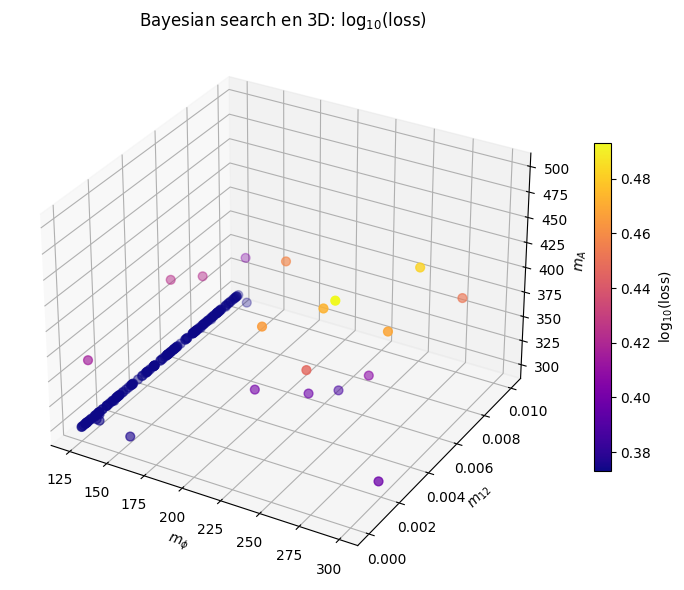

In [9]:
plot_optimization_results_3d(opt_result)

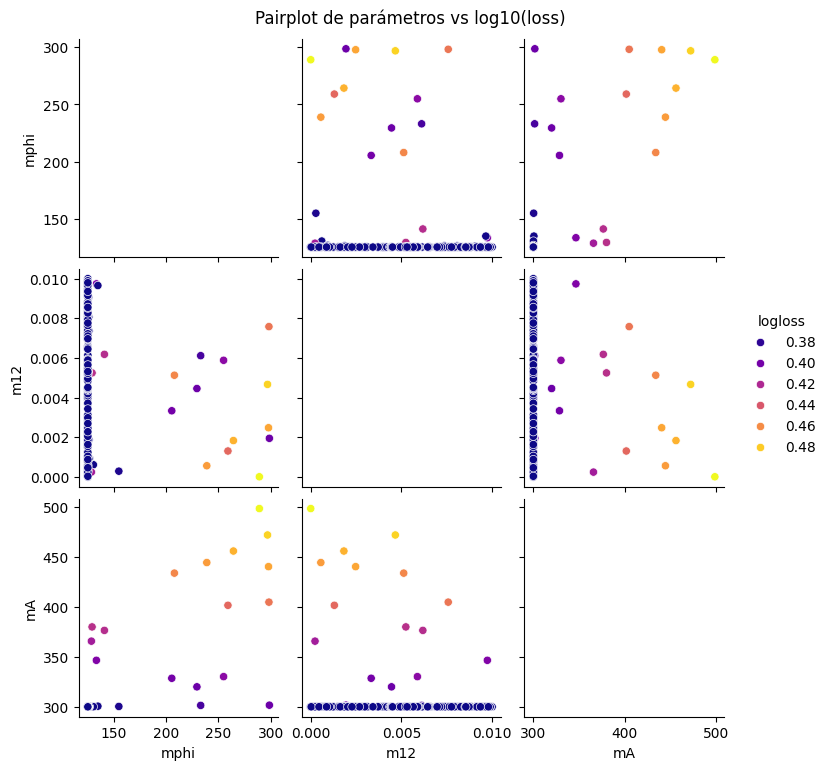

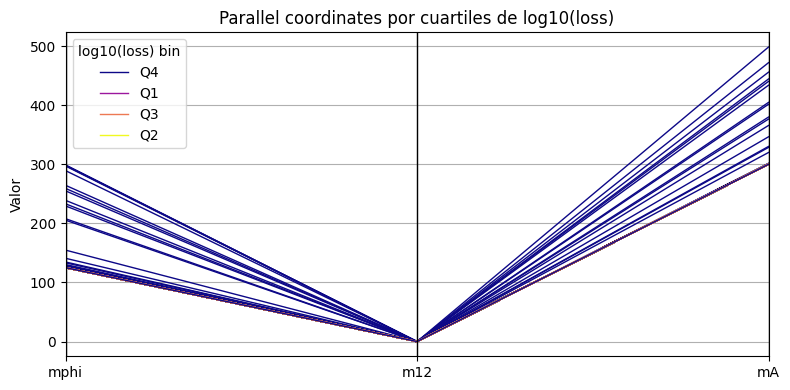

In [10]:
plot_pairwise(opt_result)

Cargar parametros previos para partir de alli

In [11]:
from joblib import load, dump

# Cargar el resultado guardado
opt_result = load("opt_result_initial.pkl")


In [ ]:

# Tu función original
# buscar luego los cambios que siguen
@use_named_args(search_space)
def loss_named(mphi, m12, ma):
    return np.log(loss(mphi, m12, ma))

# Continuar desde resultados anteriores
opt_result_extended = gp_minimize(
    loss_named,
    search_space,
    n_calls=20,  
    x0=opt_result.x_iters,  # puntos anteriores
    y0=opt_result.func_vals,
    random_state=42
)


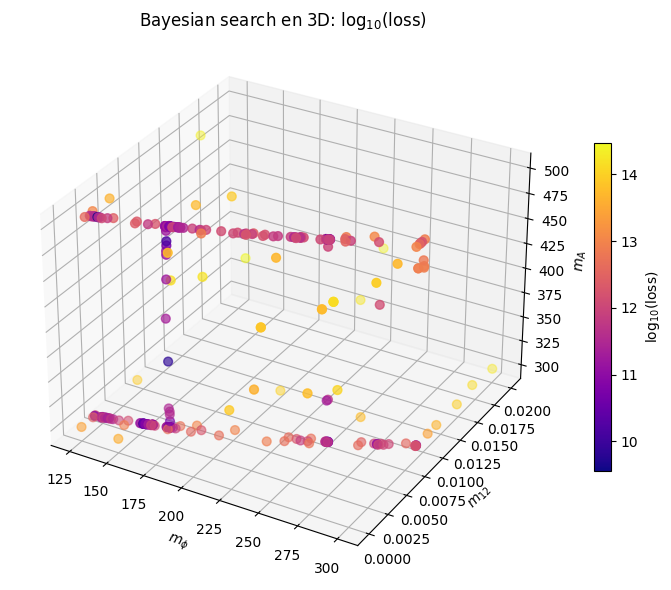

In [ ]:
plot_optimization_results_3d(opt_result_extended)

In [ ]:
type(opt_result_extended)

scipy.optimize._optimize.OptimizeResult

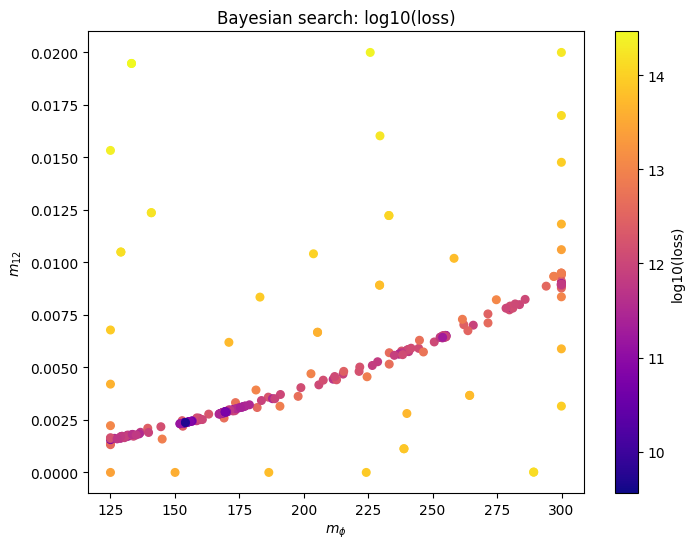

['opt_result_extended.pkl']

In [ ]:
plot_optimization_results(opt_result_extended)
dump(opt_result_extended, "opt_result_extended.pkl")


## Fitting

In [ ]:
from numpy.polynomial import Polynomial

In [ ]:
# Extraer los datos:
X = np.array(opt_result_extended.x_iters)  # shape (n_calls, 3)
y = np.array(opt_result_extended.func_vals) # loss en cada punto

# recordemos que X[:,0]=mphi, X[:,1]=m12, X[:,2]=mA

# Para cada valor único de mphi, quedarnos con el m12 que minimiza el loss
mphi_vals = np.unique(X[:,0])
best = []
for m in mphi_vals:
    mask = np.isclose(X[:,0], m, atol=1e-6)
    if not mask.any(): 
        continue
    sub_idx = np.where(mask)[0]
    # escoger el índice con el menor y
    j = sub_idx[np.argmin(y[mask])]
    best.append((m, X[j,1], y[j]))

best = np.array(best)  # shape (len(mphi_vals), 3)
mphi_best = best[:,0]
m12_best  = best[:,1]
loss_best = best[:,2]

# un primer fit para limpiar outliers
# Ajuste polinomial de grado 1 o 2
deg = 2
coefs = np.polyfit(mphi_best, m12_best, deg)
poly  = Polynomial(coefs[::-1])  # para evaluación fácil


print(f"Polinomio ajustado (deg={deg}):")
for i,c in enumerate(coefs):
    print(f"  x^{deg-i} * {c:.3e}")

Polinomio ajustado (deg=2):
  x^2 * 8.964e-08
  x^1 * 6.596e-07
  x^0 * 5.517e-04


In [ ]:
# Distancia vertical al polinomio ajustado
residuals = m12_best - poly(mphi_best)

# Calcula el MAD (median absolute deviation)
mad = np.median(np.abs(residuals - np.median(residuals)))

# Filtro de outliers: |residual| < k * MAD
k = 3
mask_inliers = np.abs(residuals) < k * mad

# Datos filtrados
mphi_in = mphi_best[mask_inliers]
m12_in  = m12_best[mask_inliers]


In [ ]:
# un segundo fit con los filtrados
deg = 2
coefs_in = np.polyfit(mphi_in, m12_in, deg)
poly_in  = Polynomial(coefs_in[::-1])  # para evaluación fácil


print(f"Filtered Polinomio ajustado (deg={deg}):")
for i,c in enumerate(coefs_in):
    print(f"  x^{deg-i} * {c:.3e}")

Filtered Polinomio ajustado (deg=2):
  x^2 * 9.653e-08
  x^1 * 1.301e-06
  x^0 * -9.184e-05


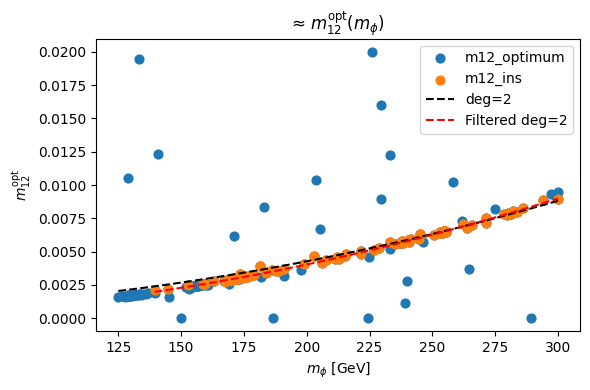

In [ ]:
# graficar datos + ajuste
mphi_plot = np.linspace(mphi_best.min(), mphi_best.max(), 200)
m12_fit   = poly(mphi_plot)

m12_fit_in = poly_in(mphi_in)

plt.figure(figsize=(6,4))
plt.scatter(mphi_best, m12_best, c='C0', label='m12_optimum', s=40)
plt.scatter(mphi_in, m12_in,  c='C1', label='m12_ins', s=40)
plt.plot(mphi_plot, m12_fit, 'k--', label=f'deg={deg}')
plt.plot(mphi_in, m12_fit_in, 'r--', label=f'Filtered deg={deg}')
plt.xlabel(r'$m_\phi$ [GeV]')
plt.ylabel(r'$m_{12}^\mathrm{opt}$')
plt.legend()
plt.title(r'≈ $m_{12}^\mathrm{opt}(m_\phi)$')
plt.tight_layout()
plt.show()


el error que presenta esta aproximacion no tiene mucho sentido, pues los puntos son solo lugares con un error cerca de ser un minimo, pero al ser un problema de fine tunning, no se encuentra del todo en el punto preciso; osea, no se puede considerar como un `true` point al que realizarlse minimizacion, pues tras una busqueda mas exahustiva o con otra seed para la aleatoriedad se podria haber obtenido

# Busqueda Extendida
Para maximizar el espacio de busqueda en caso de que existiera otra region inesperada

## Uso de Latin Hypercube Sampling

In [13]:
from skopt import gp_minimize
from skopt.space import Real, Space
from skopt.sampler import Lhs
from skopt.utils import use_named_args
import numpy as np

# Tambien

# 1) Define tu espacio
search_space = [
    Real(125.05, 299.95, name='mphi'),
    Real(0.0,   1.0,   name='m12'),
    Real(300.0, 500.0,  name='ma')
]
space = Space(search_space)

# 2) Envuelve tu función de pérdida
@use_named_args(search_space)
def loss_named(mphi, m12, ma):
    return loss(mphi, m12, ma)  # tu loss original

# 3) Genera un diseño LHS
n_lhs = 300
lhs = Lhs(criterion="maximin", iterations=1000)
X_lhs = lhs.generate(space.dimensions, n_samples=n_lhs)

# 4) Evalúa la loss en esos puntos
y_lhs = [loss_named(x) for x in X_lhs]

X_lhs, y_lhs

([[233.03653126180234, 0.4221291152275792, 356.3978399816248],
  [200.36491452231462, 0.5373448557828194, 445.82910030101107],
  [280.6522792325094, 0.5181104028654255, 430.90653004701596],
  [222.84807836643125, 0.39200419770172784, 325.4016195897277],
  [286.2787427264348, 0.4027742153679947, 370.58958593705535],
  [142.575101940834, 0.981938925577656, 355.39829172807725],
  [237.73096816347285, 0.2590468339838827, 498.1254135275497],
  [258.90892485206126, 0.7915741322083124, 468.258287860393],
  [190.40476552002838, 0.5075901540135698, 464.2804312318989],
  [133.04850082137617, 0.9691781586386302, 359.6396447247641],
  [146.8813793046117, 0.5533359571731774, 381.12679419651903],
  [141.58868975891443, 0.15239062611287035, 384.18202452744816],
  [250.21559427465633, 0.044925938942624276, 436.3557523435535],
  [191.9444432910216, 0.9978883678138302, 365.16558420377254],
  [255.48728413819288, 0.04067433758265346, 333.0982464985287],
  [246.97132688124358, 0.845755382850777, 490.92973

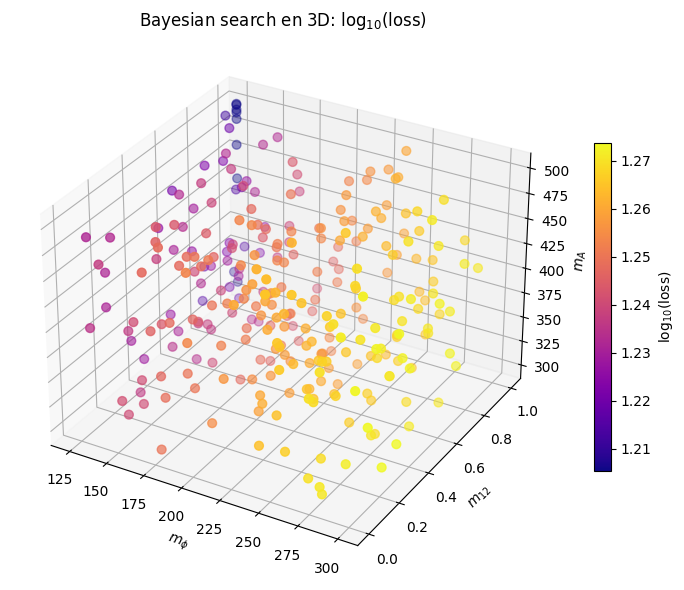

In [15]:
# 5) Lanza gp_minimize “sembrado” con LHS, sin más puntos aleatorios
opt_result = gp_minimize(
    loss_named,
    search_space,
    x0=X_lhs, 
    y0=y_lhs,
    n_calls=10,           # total de evaluaciones 
    n_initial_points=0,    # no añadir N(aleatorias) extras
    random_state=42
)

# 6) Trazar resultados
plot_optimization_results_3d(opt_result) 


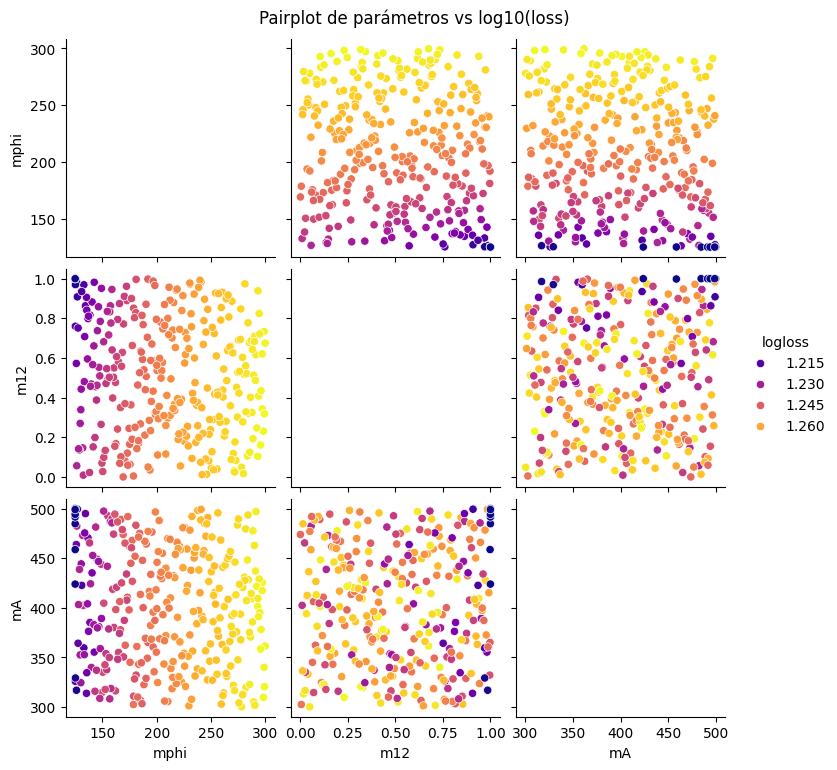

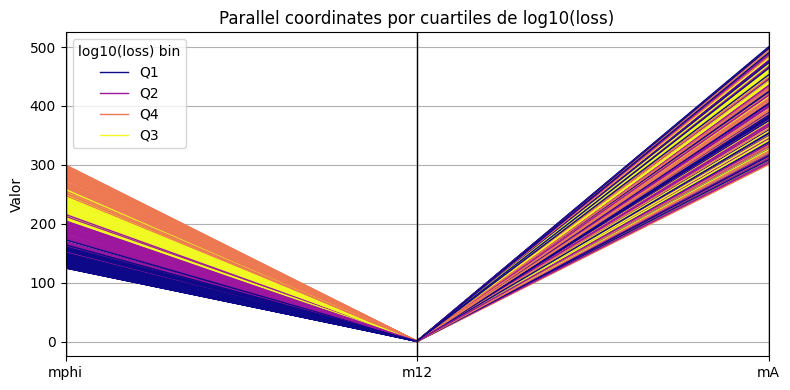

In [16]:
plot_pairwise(opt_result)

# Exploracion Sistematica

In [17]:
def evaluate_point(mphi, m12, mA=300.0):
    out = physpoint(mphi, m12, mA)
    if out is None:
        return None
    
    result = {
        'mphi': mphi,
        'm12': m12,
        'mA': mA,
        'loss': loss(mphi, m12, mA),
        'valid': is_valid(out),
        'output': out
    }
    return result

In [18]:



def auto_zoom(valid_points, factor=0.25, npts=20):
    """Genera nueva grilla local en torno a puntos válidos"""
    mphi_vals = []
    m12_vals  = []

    for p in valid_points:
        mphi = np.linspace(p['mphi']*(1-factor), p['mphi']*(1+factor), npts)
        m12  = np.linspace(p['m12'] - factor, p['m12'] + factor, npts)
        mphi_vals.extend(mphi)
        m12_vals.extend(m12)

    # Eliminar duplicados
    return list(set(mphi_vals)), list(set(m12_vals))


def run_adaptive_search(initial_mphi, initial_m12, max_loops=3, min_valid=3):
    mphi_range = initial_mphi
    m12_range  = initial_m12
    all_valid  = []

    for step in range(max_loops):
        print(f"🔍 Explorando nivel {step}...")
        valids, tested = explore_dense(mphi_range, m12_range)

        print(f"  ↪ Se encontraron {len(valids)} puntos válidos")

        all_valid.extend(valids)

        if len(valids) < min_valid:
            print("  ⚠️ Muy pocos puntos válidos — expandiendo búsqueda")
            mphi_range = np.linspace(min(initial_mphi), max(initial_mphi), len(mphi_range) + 10)
            m12_range  = np.linspace(min(initial_m12), max(initial_m12), len(m12_range) + 10)
        else:
            mphi_range, m12_range = auto_zoom(valids)

    return all_valid
